## Form factor integration approach study
This notebook will hold some methods to evaluate different approaches for the integration of form factors

In [19]:
from examples.utils.trace_integration import integration_test as intt
import numpy as np
import matplotlib.pyplot as plt
import sparrowpy as sp
import pyfar as pf
from time import time

In [20]:
integration = intt(ww=1, hh=1, ll=1, gtype="b")

In [21]:
def plotting_options(in_dict):
    options = {"color": None, "line": None, "marker": ""}

    match in_dict["method"]:
        case "contour":
            options["line"] = "solid"
        case "naive":
            options["line"] = "dashed"
        case "nusselt":
            options["line"] = "dotted"

    if in_dict["int1"] == "analytical":
        options["line"] = "-."

    match in_dict["int2"]:
        case "random":
            options["color"] = "forestgreen"
        case "regular":
            options["color"] = "navy"
        case "poly_NC":
            options["color"] = "firebrick"
        case "poly_GL":
            options["color"] = "coral"

    return options

In [22]:
order_arr = np.arange(1, 6)
out = []
for method in ["naive", "contour"]:
    if method == "contour":
        opp1 = ["analytical", "poly_GL", "poly_NC"]
    else:
        opp1 = ["regular", "random", "poly_NC", "poly_GL"]

    for op1 in opp1:
        if op1 == "analytical":
            opp2 = ["poly_GL", "poly_NC"]
        else:
            opp2 = [op1]

        for op2 in opp2:
            if op2 == "poly_GL" or op2 == "poly_NC":
                oorder = order_arr[order_arr < 4]
            else:
                oorder = order_arr

            out.append(
                {
                    "method": method,
                    "int1": op1,
                    "int2": op2,
                    "order": [],
                    "runtime": [],
                    "memory": [],
                    "rel_error": [],
                },
            )

            for poly_order in oorder:
                integration.set_poly_order(poly_order)
                integration.set_int_method(op1=method, op2=op1, op3=op2)
                integration.print_stats()
                tim = integration.integrate(trace_time=True, n=100)
                integration.print_results()
                err = integration.error
                mem = integration.integrate(trace_mem=True)

                out[-1]["order"].append(poly_order)
                out[-1]["runtime"].append(tim * 1000)
                out[-1]["memory"].append(mem / 1000)
                out[-1]["rel_error"].append(np.abs((err - 1) * 100))



############################################
Form Factor approach: naive
Integral approach: regular
# of samples in each patch: 4

 -> relative ff error:       31.9942%
 -> gain per 100 bounces:      120.6dB



############################################
Form Factor approach: naive
Integral approach: regular
# of samples in each patch: 9

 -> relative ff error:       21.7558%
 -> gain per 100 bounces:      85.5dB



############################################
Form Factor approach: naive
Integral approach: regular
# of samples in each patch: 16

 -> relative ff error:       16.4704%
 -> gain per 100 bounces:      66.2dB



############################################
Form Factor approach: naive
Integral approach: regular
# of samples in each patch: 25

 -> relative ff error:       13.2490%
 -> gain per 100 bounces:      54.0dB



############################################
Form Factor approach: naive
Integral approach: regular
# of samples in each patch: 36

 -> relative ff error: 

C:\Users\jotag\Documents\dev\sparrowpy\sparrowpy\form_factor\integration.py:327: RuntimeWarning: divide by zero encountered in log
  form_mat[i][j] = np.log(



 -> relative ff error:       inf%
 -> gain per 100 bounces:      infdB



############################################
Form Factor approach: contour
Internal integral approach: poly_GL
External integral approach: poly_GL
Polynomial order: 2

 -> relative ff error:       inf%
 -> gain per 100 bounces:      infdB



############################################
Form Factor approach: contour
Internal integral approach: poly_GL
External integral approach: poly_GL
Polynomial order: 3

 -> relative ff error:       inf%
 -> gain per 100 bounces:      infdB



############################################
Form Factor approach: contour
Internal integral approach: poly_NC
External integral approach: poly_NC
Polynomial order: 1

 -> relative ff error:       inf%
 -> gain per 100 bounces:      infdB



############################################
Form Factor approach: contour
Internal integral approach: poly_NC
External integral approach: poly_NC
Polynomial order: 2

 -> relative ff error:       in

C:\Users\jotag\Documents\dev\sparrowpy\sparrowpy\form_factor\integration.py:136: RuntimeWarning: invalid value encountered in scalar multiply
  out -= c[i] * x[0] ** (len(c) - i) / (len(c) - i)
C:\Users\jotag\Documents\dev\sparrowpy\sparrowpy\form_factor\integration.py:135: RuntimeWarning: invalid value encountered in scalar multiply
  out += c[i] * x[-1] ** (len(c) - i) / (len(c) - i)



 -> relative ff error:       nan%
 -> gain per 100 bounces:      nandB



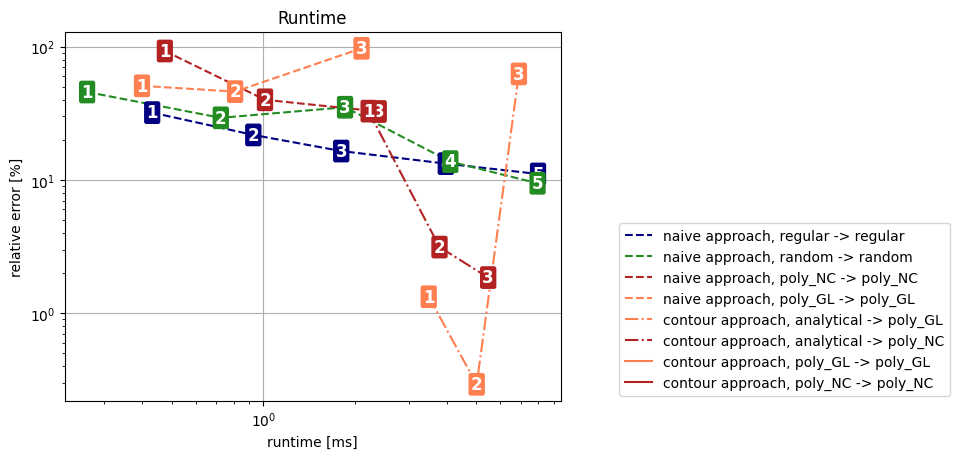

In [23]:
plt.figure()
for entry in out:
    options = plotting_options(entry)
    plt.loglog(
        entry["runtime"],
        entry["rel_error"],
        linestyle=options["line"],
        marker=options["marker"],
        color=options["color"],
        label=f"{entry['method']} approach, {entry['int1']} -> {entry['int2']}",
    )
    for i, (x, y) in enumerate(zip(entry["runtime"], entry["rel_error"])):
        plt.text(
            x,
            y,
            entry["order"][i],
            horizontalalignment="center",
            verticalalignment="center",
            color="white",
            bbox={
                "facecolor": options["color"],
                "edgecolor": options["color"],
                "boxstyle": "round",
                "pad": 0.1,
            },
            weight="bold",
            fontsize=12,
        )

plt.xlabel("runtime [ms]")
plt.ylabel("relative error [%]")
plt.title("Runtime")
plt.legend(bbox_to_anchor=(1.8, 0.5))
plt.grid()
plt.show()


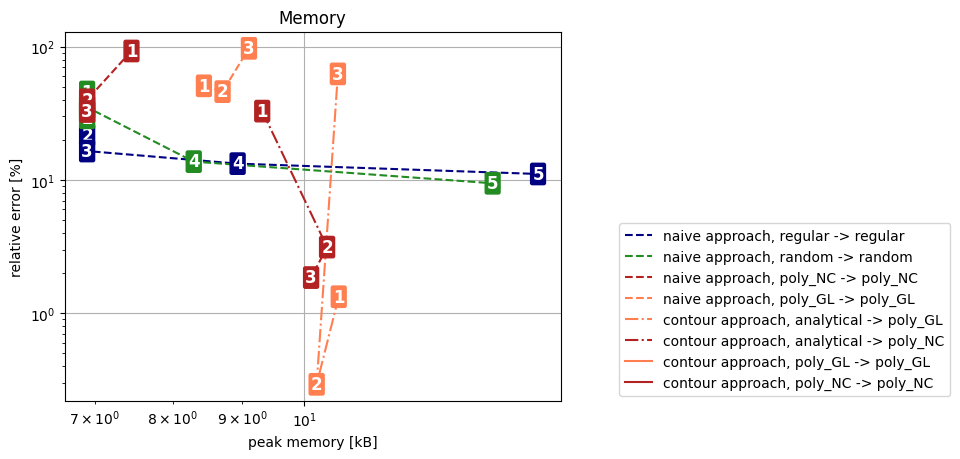

In [24]:
plt.figure()
for entry in out:
    options = plotting_options(entry)
    plt.loglog(
        entry["memory"],
        entry["rel_error"],
        linestyle=options["line"],
        marker=options["marker"],
        color=options["color"],
        label=f"{entry['method']} approach, {entry['int1']} -> {entry['int2']}",
    )
    for i, (x, y) in enumerate(zip(entry["memory"], entry["rel_error"])):
        plt.text(
            x,
            y,
            entry["order"][i],
            horizontalalignment="center",
            verticalalignment="center",
            color="white",
            bbox={
                "facecolor": options["color"],
                "edgecolor": options["color"],
                "boxstyle": "round",
                "pad": 0.1,
            },
            weight="bold",
            fontsize=12,
        )
plt.xlabel("peak memory [kB]")
plt.ylabel("relative error [%]")
plt.title("Memory")
plt.legend(bbox_to_anchor=(1.8, 0.5))
plt.grid()
plt.show()

In [ ]:
# Define parameters
X = 4
Y = 4
Z = 4
ppatch_size = [4, 2, 4 / 3, 1]
etc_duration = 1
etc_time_resolution = 1 / 500
max_reflection_order = 150
speed_of_sound = 343.2
absorption = 0.1

# create geometry
walls = sp.testing.shoebox_room_stub(X, Y, Z)
source = pf.Coordinates(2, 2, 2)
receiver = pf.Coordinates(2, 3, 2)

contour; analytical-poly_GL integration (order 2)

C:\Users\jotag\Documents\dev\sparrowpy\sparrowpy\geometry.py:379: RuntimeWarning: invalid value encountered in divide
  real_size = size/patch_nums
C:\Users\jotag\AppData\Local\Temp\ipykernel_26404\22888704.py:50: UserWarning: Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.
  radiosity_fast.set_wall_brdf(


   ...   (0.12280654907226562s)
naive; random-random integration (order 7)   ...   (0.3994474411010742s)
naive; regular-regular integration (order 7)   ...   (0.4007089138031006s)
reverberation distance is 0.4m
reverberation time is 1.02s


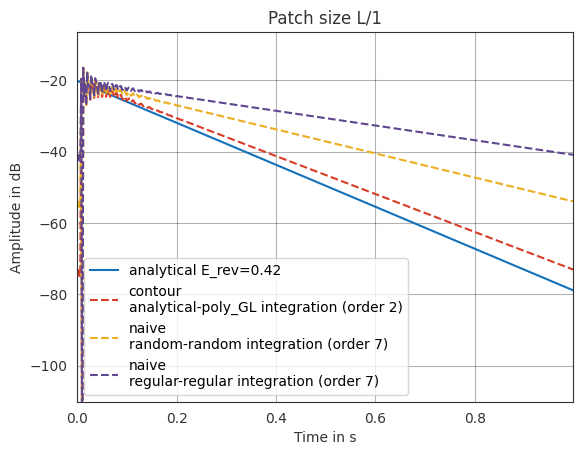

contour; analytical-poly_GL integration (order 2)

C:\Users\jotag\Documents\dev\sparrowpy\sparrowpy\geometry.py:379: RuntimeWarning: invalid value encountered in divide
  real_size = size/patch_nums
C:\Users\jotag\AppData\Local\Temp\ipykernel_26404\22888704.py:50: UserWarning: Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.
  radiosity_fast.set_wall_brdf(


   ...   (2.1163487434387207s)
naive; random-random integration (order 7)   ...   (6.849696397781372s)
naive; regular-regular integration (order 7)   ...   (6.781268119812012s)
reverberation distance is 0.4m
reverberation time is 1.02s


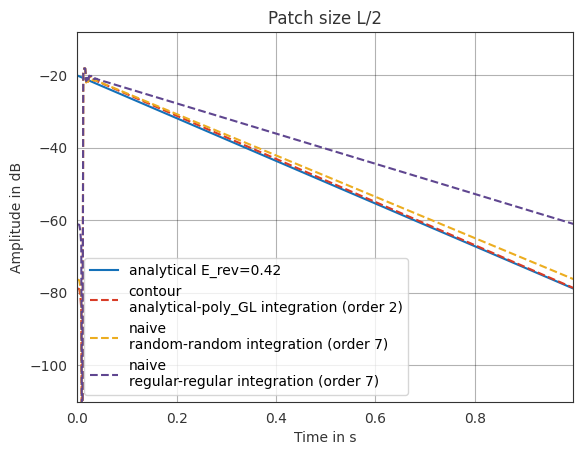

contour; analytical-poly_GL integration (order 2)

C:\Users\jotag\Documents\dev\sparrowpy\sparrowpy\geometry.py:379: RuntimeWarning: invalid value encountered in divide
  real_size = size/patch_nums
C:\Users\jotag\AppData\Local\Temp\ipykernel_26404\22888704.py:50: UserWarning: Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.
  radiosity_fast.set_wall_brdf(


In [ ]:
integration_args = [
    {
        "method": "contour",
        "int1": "analytical",
        "int2": "poly_GL",
        "order": 2,
    },
    {
        "method": "naive",
        "int1": "random",
        "int2": "random",
        "order": 7,
    },
    {
        "method": "naive",
        "int1": "regular",
        "int2": "regular",
        "order": 7,
    },
]


for patch_size in ppatch_size:
    etc_radiosity = []
    for i, args in enumerate(integration_args):
        print(
            f"{integration_args[i]['method']}; {integration_args[i]['int1']}"
            + f"-{integration_args[i]['int2']} integration"
            + f" (order {integration_args[i]['order']})",
            end="",
        )
        t0 = time()
        # create object
        radiosity_fast = sp.DirectionalRadiosityFast.from_polygon(
            walls,
            patch_size,
        )
        # create directional scattering data (totally diffuse)
        brdf_sources = pf.Coordinates(0, 0, 1, weights=1)
        brdf_receivers = pf.Coordinates(0, 0, 1, weights=1)
        frequencies = np.array([1000])
        brdf = sp.brdf.create_from_scattering(
            brdf_sources,
            brdf_receivers,
            pf.FrequencyData(1, frequencies),
            pf.FrequencyData(absorption, frequencies),
        )

        # set directional scattering data
        radiosity_fast.set_wall_brdf(
            np.arange(len(walls)), brdf, brdf_sources, brdf_receivers
        )
        # set air absorption
        radiosity_fast.set_air_attenuation(
            pf.FrequencyData(np.zeros_like(brdf.frequencies), brdf.frequencies)
        )
        # calculate from factors including brdfs
        radiosity_fast.bake_geometry(integration_args=args)
        radiosity_fast.init_source_energy(source)
        radiosity_fast.calculate_energy_exchange(
            speed_of_sound=speed_of_sound,
            etc_time_resolution=etc_time_resolution,
            etc_duration=etc_duration,
            max_reflection_order=max_reflection_order,
        )
        etc_radiosity.append(
            radiosity_fast.collect_energy_receiver_mono(receivers=receiver),
        )
        print(f"   ...   ({time() - t0}s)")
        del radiosity_fast

    S = (2 * X * Y) + (2 * X * Z) + (2 * Y * Z)
    A = S * absorption
    alpha_dash = A / S
    r_h = 1 / 4 * np.sqrt(A / np.pi)
    print(f"reverberation distance is {r_h:.1f}m")
    V = X * Y * Z
    RT = 24 * np.log(10) / (speed_of_sound) * V / (-S * np.log(1 - alpha_dash))
    print(f"reverberation time is {RT:.2f}s")
    E_reverb_analytical = 4 / A
    t = etc_radiosity[0].times
    # Kuttruff Eq 4.7
    w_0 = E_reverb_analytical / V
    t_0 = 0.03
    # Kuttruff Eq 4.10
    reverberation_analytic = w_0 * np.exp(
        +(speed_of_sound * S * np.log(1 - alpha_dash) / (4 * V)) * (t - t_0)
    )
    reverberation_analytic = pf.TimeData(reverberation_analytic, t)

    plt.figure()
    pf.plot.time(
        reverberation_analytic,
        dB=True,
        log_prefix=10,
        label=f"analytical E_rev={E_reverb_analytical:0.2f}",
    )
    for i, rad in enumerate(etc_radiosity):
        pf.plot.time(
            rad,
            dB=True,
            log_prefix=10,
            label=f"{integration_args[i]['method']}\n{integration_args[i]['int1']} -> {integration_args[i]['int2']} integration\n(order {integration_args[i]['order']})",
            linestyle="--",
        )

    plt.title(f"Patch size L/{int(X / patch_size)}")

    plt.legend()
    plt.show()


reverberation distance is 0.4m
reverberation time is 1.02s


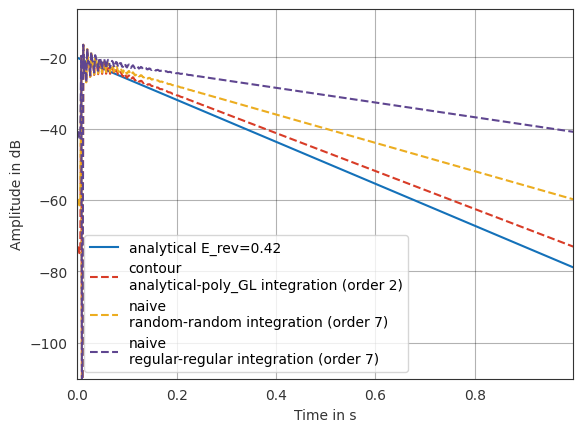